In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!gdown 1eZacx60WWzwZrEbrHKD45vl9yoKLUHyE

Downloading...
From: https://drive.google.com/uc?id=1eZacx60WWzwZrEbrHKD45vl9yoKLUHyE
To: /content/split_pca11_densenet.zip
100% 61.1k/61.1k [00:00<00:00, 118MB/s]


In [ ]:
!gdown 1Rw-q8BRrJ7hBT9ZfM7JKHBwyipCFMTDf

Downloading...
From (original): https://drive.google.com/uc?id=1Rw-q8BRrJ7hBT9ZfM7JKHBwyipCFMTDf
From (redirected): https://drive.google.com/uc?id=1Rw-q8BRrJ7hBT9ZfM7JKHBwyipCFMTDf&confirm=t&uuid=05b6c7c1-bbeb-4e55-9b5c-b5976cf62277
To: /content/PCA11_dataset.zip
100% 559M/559M [00:06<00:00, 90.3MB/s]


In [ ]:
import os
import zipfile

zip_path = '/content/PCA11_dataset.zip'
extract_dir = '/content/pca11-dataset'

# Tạo folder nếu chưa tồn tại
os.makedirs(extract_dir, exist_ok=True)

# Giải nén vào folder
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Đã giải nén vào thư mục: {extract_dir}")


Đã giải nén vào thư mục: /content/pca11-dataset


In [ ]:
!unzip '/content/split_pca11_densenet.zip'

Archive:  /content/split_pca11_densenet.zip
  inflating: split_pca11_densenet/split_config.json  
  inflating: split_pca11_densenet/test_split_optimized.json  
  inflating: split_pca11_densenet/train_split_optimized.json  


In [ ]:
import json
from pathlib import Path

# Hàm đổi đường dẫn
def convert_path(old_path):
    return old_path.replace("/kaggle/input", "/content")

# Xử lý 1 file json
def process_json(input_file, output_file):
    with open(input_file, "r") as f:
        data = json.load(f)

    for item in data:
        if "file_path" in item:
            item["file_path"] = convert_path(item["file_path"])

    with open(output_file, "w") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)

# Ví dụ chạy cho 2 file
process_json("/content/split_pca11_densenet/train_split_optimized.json", "train_split_converted.json")
process_json("/content/split_pca11_densenet/test_split_optimized.json", "test_split_converted.json")

print("Hoàn tất chuyển đổi đường dẫn!")


Hoàn tất chuyển đổi đường dẫn!


In [ ]:
import json
import os
import shutil

# Định nghĩa đường dẫn đến file JSON
train_json_path = "/content/train_split_converted.json"
test_json_path = "/content/test_split_converted.json"

# Định nghĩa thư mục đích để lưu ảnh
train_dir = "train"
test_dir = "test"

# Hàm để đọc file JSON
def read_json_file(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    return data

# Hàm để tạo thư mục nếu chưa tồn tại
def create_directory(directory):
    if not os.path.exists(directory):
        os.makedirs(directory)

# Hàm để sao chép ảnh vào thư mục tương ứng
def copy_images(json_data, destination_dir):
    for item in json_data:
        # Lấy đường dẫn ảnh và tên lớp
        file_path = item['file_path']
        class_name = item['class_name']

        # Tạo thư mục con theo tên lớp trong thư mục đích
        class_dir = os.path.join(destination_dir, class_name)
        create_directory(class_dir)

        # Tạo đường dẫn đích cho file ảnh
        file_name = os.path.basename(file_path)
        destination_path = os.path.join(class_dir, file_name)

        try:
            # Kiểm tra xem file ảnh có tồn tại không
            if os.path.exists(file_path):
                shutil.copy(file_path, destination_path)
            else:
                print(f"File not found: {file_path}")
        except Exception as e:
            print(f"Error copying {file_name}: {str(e)}")

# Đọc dữ liệu từ file JSON
train_data = read_json_file(train_json_path)
test_data = read_json_file(test_json_path)

# Tạo thư mục train và test
create_directory(train_dir)
create_directory(test_dir)

# Sao chép ảnh vào thư mục train
print("Copying images to train directory...")
copy_images(train_data, train_dir)

# Sao chép ảnh vào thư mục test
print("Copying images to test directory...")
copy_images(test_data, test_dir)

print("Process completed!")

Copying images to train directory...
Copying images to test directory...
Process completed!


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

train_dir = '/content/train'
val_dir = '/content/val'
os.makedirs(val_dir, exist_ok=True)

for class_name in os.listdir(train_dir):
    class_train_dir = os.path.join(train_dir, class_name)
    class_val_dir = os.path.join(val_dir, class_name)
    os.makedirs(class_val_dir, exist_ok=True)

    files = os.listdir(class_train_dir)
    # Tách 10/70 ≈ 14.3% từ train hiện tại để có 10% của tổng dữ liệu
    train_files, val_files = train_test_split(files, test_size=0.143, random_state=42)

    for file in val_files:
        src = os.path.join(class_train_dir, file)
        dst = os.path.join(class_val_dir, file)
        shutil.move(src, dst)

In [ ]:
%cd ultralytics
!pip install -e .

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 44.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
 

In [ ]:
!python train.py

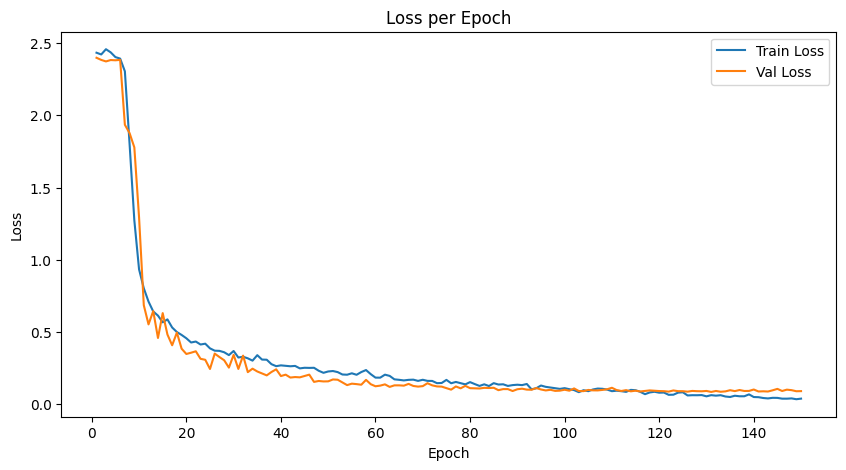

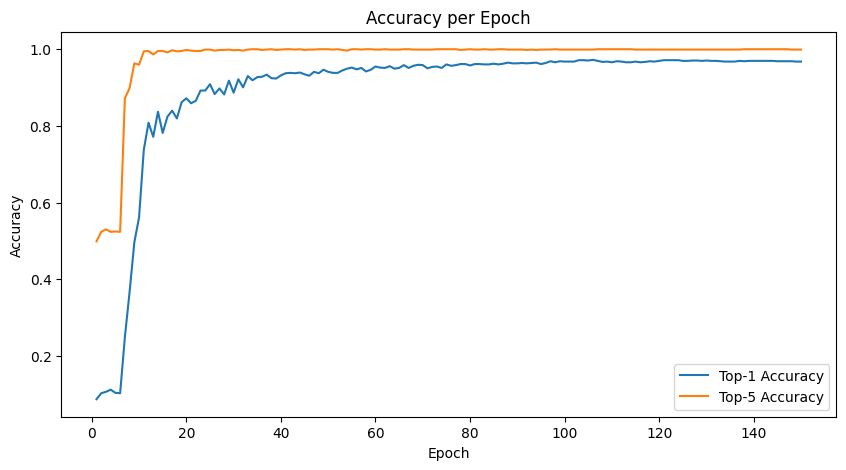

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Đường dẫn đến file results.csv (bạn thay bằng đường dẫn thực tế)
csv_path = '/content/yolo_cls_results/train/results.csv'

# Đọc dữ liệu từ file csv
df = pd.read_csv(csv_path)

# Vẽ loss
plt.figure(figsize=(10,5))
plt.plot(df['epoch'], df['train/loss'], label='Train Loss')
if 'val/loss' in df.columns:
    plt.plot(df['epoch'], df['val/loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss per Epoch')
plt.legend()
plt.show()

# Vẽ accuracy
plt.figure(figsize=(10,5))
plt.plot(df['epoch'], df['metrics/accuracy_top1'], label='Top-1 Accuracy')
plt.plot(df['epoch'], df['metrics/accuracy_top5'], label='Top-5 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy per Epoch')
plt.legend()
plt.show()

Số lượng class: 11
Danh sách class: ['Achapo', 'Cedro costeño', 'Chanul', 'Cipres', 'Cuangare', 'Eucalipto blanco', 'Guayacan amarillo', 'Nogal cafetero', 'Pino patula', 'Sajo', 'Urapan']
Đang thu thập dữ liệu test...
Class Achapo: 349 ảnh
Class Cedro costeño: 341 ảnh
Class Chanul: 310 ảnh
Class Cipres: 250 ảnh
Class Cuangare: 320 ảnh
Class Eucalipto blanco: 332 ảnh
Class Guayacan amarillo: 335 ảnh
Class Nogal cafetero: 272 ảnh
Class Pino patula: 175 ảnh
Class Sajo: 246 ảnh
Class Urapan: 307 ảnh
Tổng số ảnh test: 3237

===== INFERENCE TOÀN BỘ TẬP TEST =====
Bắt đầu chạy inference trên toàn bộ dữ liệu...


100%|██████████| 51/51 [00:30<00:00,  1.69it/s]



Thời gian inference trung bình: 0.0092 giây/ảnh
Tổng thời gian inference: 29.91 giây

===== TỔNG KẾT KẾT QUẢ ĐÁNH GIÁ TOÀN BỘ TẬP TEST =====
Accuracy: 0.9682
Macro Precision: 0.9668
Macro Recall: 0.9669
Macro F1-score: 0.9665
Weighted Precision: 0.9691
Weighted Recall: 0.9682
Weighted F1-score: 0.9683

Báo cáo phân loại chi tiết theo class:
                   precision    recall  f1-score   support

           Achapo       0.98      1.00      0.99       349
    Cedro costeño       0.91      0.98      0.94       341
           Chanul       0.98      0.98      0.98       310
           Cipres       0.97      0.92      0.94       250
         Cuangare       0.96      0.95      0.95       320
 Eucalipto blanco       0.99      0.98      0.99       332
Guayacan amarillo       0.98      0.96      0.97       335
   Nogal cafetero       0.99      0.99      0.99       272
      Pino patula       0.89      0.95      0.92       175
             Sajo       1.00      0.98      0.99       246
      

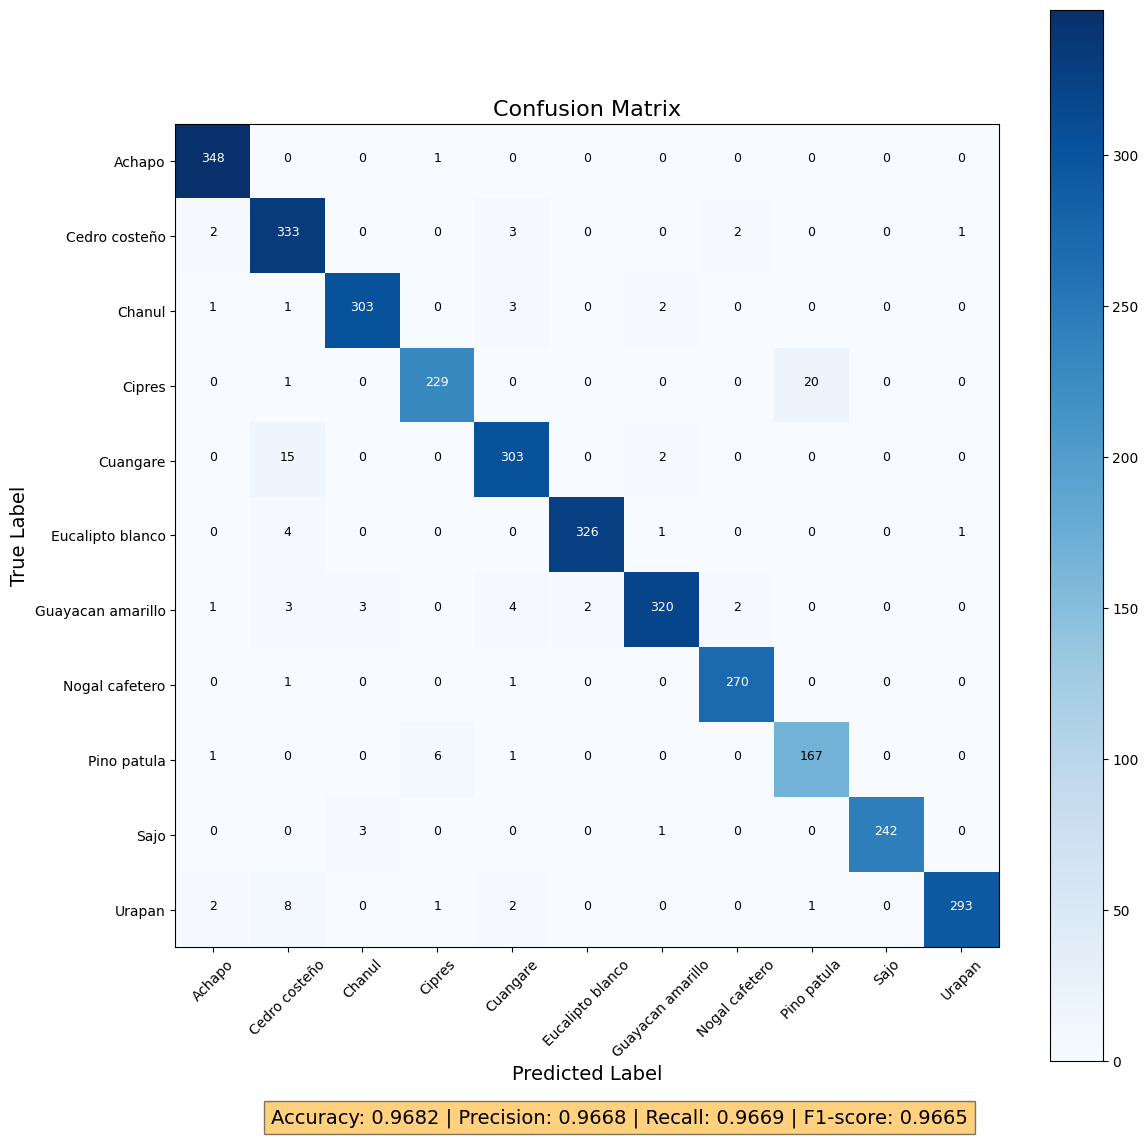

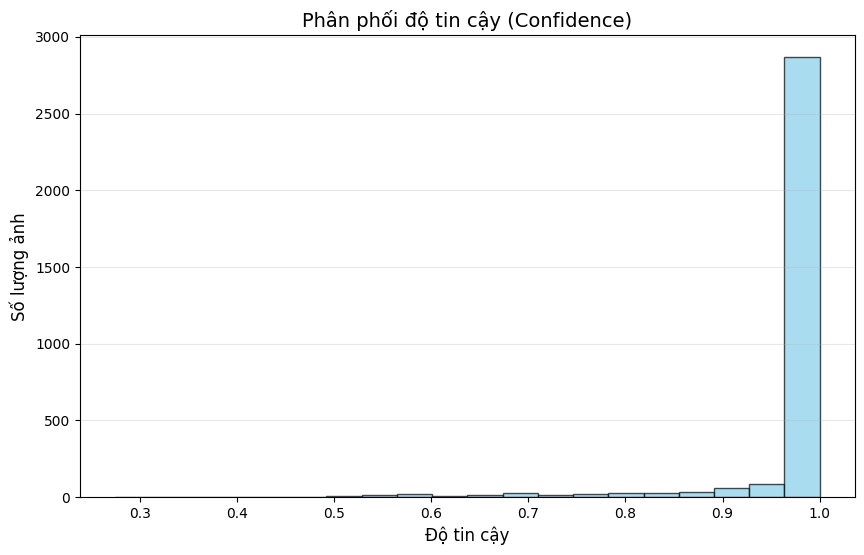


Hiển thị một số mẫu dự đoán:


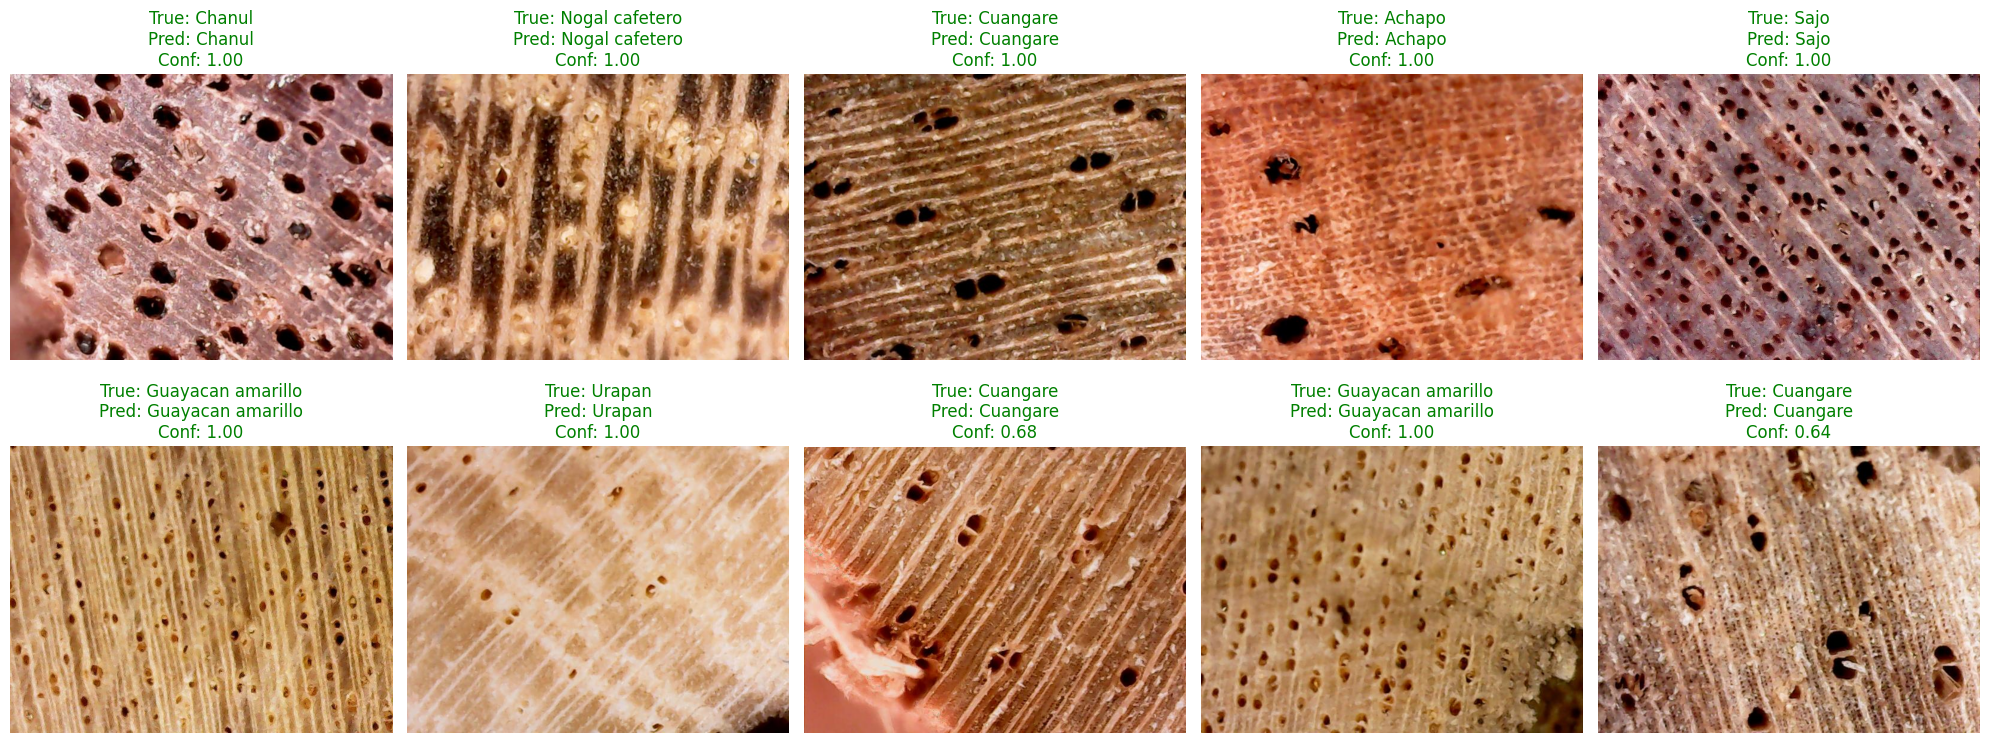


Số lượng dự đoán đúng: 3134/3237 (96.82%)
Số lượng dự đoán sai: 103/3237 (3.18%)

Một số ví dụ dự đoán sai:


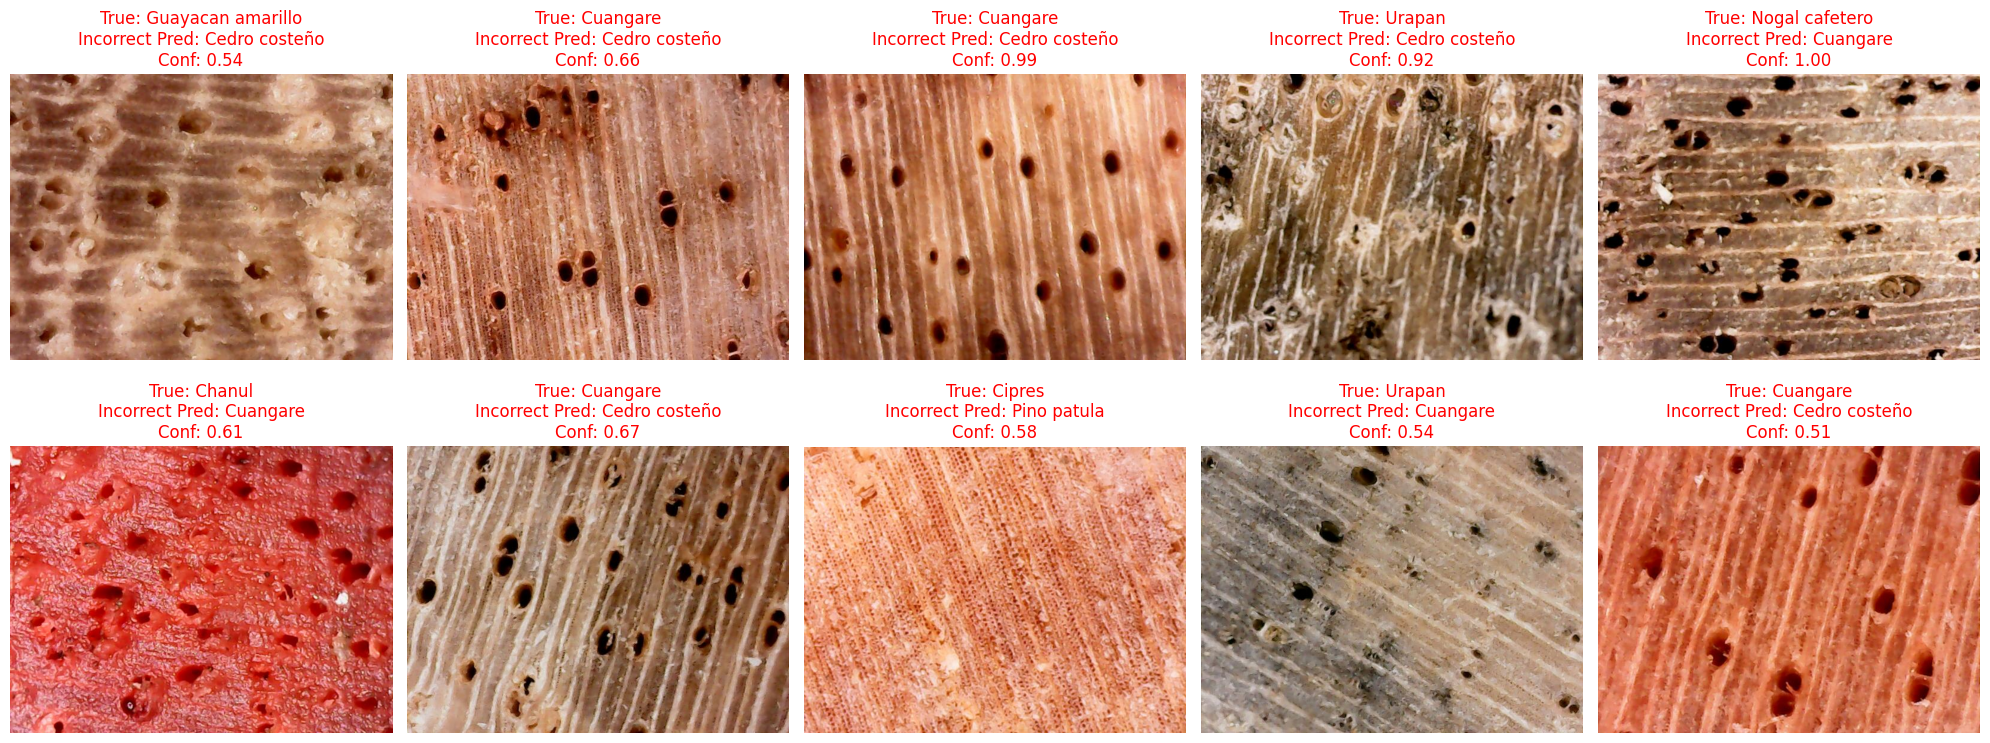

In [ ]:
# Cài đặt thư viện nếu chưa có
# !pip install ultralytics matplotlib Pillow tqdm

import time
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import YOLO
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, accuracy_score

# Cấu hình đường dẫn và model
test_dir = '/content/test'  # Thay bằng đường dẫn thực tế
model_path = '/content/yolo_cls_results/train/weights/best.pt'  # Đường dẫn đến model đã train, thay đổi nếu cần

# Tải model
model = YOLO(model_path)

# Lấy danh sách class từ thư mục test
classes = sorted(os.listdir(test_dir))
print(f"Số lượng class: {len(classes)}")
print(f"Danh sách class: {classes}")

# Hàm để thu thập tất cả ảnh từ tập test
def get_all_test_images(test_dir):
    image_paths = []
    true_labels = []

    for cls in classes:
        cls_dir = os.path.join(test_dir, cls)
        if not os.path.isdir(cls_dir):
            continue

        cls_images = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir)
                      if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

        image_paths.extend(cls_images)
        true_labels.extend([cls] * len(cls_images))

        print(f"Class {cls}: {len(cls_images)} ảnh")

    return image_paths, true_labels

# Thu thập tất cả ảnh test
print("Đang thu thập dữ liệu test...")
all_image_paths, all_true_labels = get_all_test_images(test_dir)
print(f"Tổng số ảnh test: {len(all_image_paths)}")

# Thông số cấu hình
batch_size = 64  # Có thể điều chỉnh tùy theo khả năng của GPU
img_size = 224   # Kích thước ảnh đầu vào

# Lưu kết quả dự đoán
all_predictions = []
all_confidences = []
total_infer_time = 0

# ================ INFERENCE TOÀN BỘ TẬP TEST ================
print("\n===== INFERENCE TOÀN BỘ TẬP TEST =====")
print("Bắt đầu chạy inference trên toàn bộ dữ liệu...")
for i in tqdm(range(0, len(all_image_paths), batch_size)):
    batch_paths = all_image_paths[i:i+batch_size]

    # Đo thời gian inference
    start_time = time.time()
    results = model.predict(source=batch_paths, imgsz=img_size, verbose=False)
    batch_time = time.time() - start_time
    total_infer_time += batch_time

    # Lấy kết quả dự đoán cho mỗi ảnh trong batch
    for result in results:
        pred_class_id = result.probs.top1
        pred_label = result.names[pred_class_id]
        confidence = result.probs.top1conf.item()

        all_predictions.append(pred_label)
        all_confidences.append(confidence)

# Tính toán các chỉ số đánh giá tổng thể
accuracy = accuracy_score(all_true_labels, all_predictions)
precision = precision_score(all_true_labels, all_predictions, average='macro')
recall = recall_score(all_true_labels, all_predictions, average='macro')
f1 = f1_score(all_true_labels, all_predictions, average='macro')

# Tính weighted metrics
weighted_precision = precision_score(all_true_labels, all_predictions, average='weighted')
weighted_recall = recall_score(all_true_labels, all_predictions, average='weighted')
weighted_f1 = f1_score(all_true_labels, all_predictions, average='weighted')

# Hiển thị thời gian inference
average_time = total_infer_time / len(all_image_paths)
print(f"\nThời gian inference trung bình: {average_time:.4f} giây/ảnh")
print(f"Tổng thời gian inference: {total_infer_time:.2f} giây")

# Hiển thị kết quả tổng thể
print("\n===== TỔNG KẾT KẾT QUẢ ĐÁNH GIÁ TOÀN BỘ TẬP TEST =====")
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall: {recall:.4f}")
print(f"Macro F1-score: {f1:.4f}")
print(f"Weighted Precision: {weighted_precision:.4f}")
print(f"Weighted Recall: {weighted_recall:.4f}")
print(f"Weighted F1-score: {weighted_f1:.4f}")

# Hiển thị báo cáo phân loại chi tiết cho tham khảo
print("\nBáo cáo phân loại chi tiết theo class:")
print(classification_report(all_true_labels, all_predictions, target_names=classes))

# Tạo confusion matrix với thông tin tổng quát
cm = confusion_matrix(all_true_labels, all_predictions, labels=classes)
plt.figure(figsize=(12, 12))

# Hiển thị confusion matrix với màu phân loại
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix', fontsize=16)
plt.colorbar()

# Thiết lập nhãn các trục
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45, fontsize=10)
plt.yticks(tick_marks, classes, fontsize=10)

# Thêm giá trị vào ô trong confusion matrix
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontsize=9)

# Tạo tiêu đề và thêm thông tin của các metrics vào hình ảnh
plt.figtext(0.5, 0.01, f"Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1-score: {f1:.4f}",
            ha="center", fontsize=14, bbox={"facecolor":"orange", "alpha":0.5, "pad":5})

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.savefig('confusion_matrix_with_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

# Hiển thị phân phối độ tin cậy
plt.figure(figsize=(10, 6))
plt.hist(all_confidences, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Phân phối độ tin cậy (Confidence)', fontsize=14)
plt.xlabel('Độ tin cậy', fontsize=12)
plt.ylabel('Số lượng ảnh', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.savefig('confidence_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Hiển thị một số ví dụ dự đoán (lấy mẫu ngẫu nhiên để hiển thị)
def show_sample_predictions(image_paths, true_labels, predictions, confidences, num_samples=10):
    # Chọn ngẫu nhiên num_samples ảnh
    indices = np.random.choice(len(image_paths), min(num_samples, len(image_paths)), replace=False)

    # Tạo lưới hình ảnh
    fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 8)) if num_samples >= 10 else plt.subplots(nrows=1, ncols=num_samples, figsize=(20, 4))
    axes = axes.flatten()

    for i, idx in enumerate(indices):
        if i >= len(axes):
            break

        img = Image.open(image_paths[idx])
        true_label = true_labels[idx]
        pred_label = predictions[idx]
        conf = confidences[idx]

        # Hiển thị ảnh
        axes[i].imshow(img)

        # Thêm nhãn
        color = 'green' if true_label == pred_label else 'red'
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}\nConf: {conf:.2f}", color=color)
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig('sample_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()

# Hiển thị một số mẫu dự đoán ngẫu nhiên
print("\nHiển thị một số mẫu dự đoán:")
show_sample_predictions(all_image_paths, all_true_labels, all_predictions, all_confidences, num_samples=10)

# Phân tích dự đoán đúng và sai
correct_indices = [i for i, (true, pred) in enumerate(zip(all_true_labels, all_predictions)) if true == pred]
incorrect_indices = [i for i, (true, pred) in enumerate(zip(all_true_labels, all_predictions)) if true != pred]

print(f"\nSố lượng dự đoán đúng: {len(correct_indices)}/{len(all_image_paths)} ({len(correct_indices)/len(all_image_paths):.2%})")
print(f"Số lượng dự đoán sai: {len(incorrect_indices)}/{len(all_image_paths)} ({len(incorrect_indices)/len(all_image_paths):.2%})")

# Hiển thị một số ví dụ dự đoán sai
if len(incorrect_indices) > 0:
    print("\nMột số ví dụ dự đoán sai:")
    sample_incorrect = np.random.choice(incorrect_indices, min(10, len(incorrect_indices)), replace=False)

    fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 8)) if len(sample_incorrect) >= 10 else plt.subplots(nrows=1, ncols=len(sample_incorrect), figsize=(20, 4))
    if len(sample_incorrect) == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, idx in enumerate(sample_incorrect):
        if i >= len(axes):
            break

        img = Image.open(all_image_paths[idx])
        true_label = all_true_labels[idx]
        pred_label = all_predictions[idx]
        conf = all_confidences[idx]

        axes[i].imshow(img)
        axes[i].set_title(f"True: {true_label}\nIncorrect Pred: {pred_label}\nConf: {conf:.2f}", color='red')
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig('incorrect_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()

# Lưu kết quả vào file
results_dict = {
    'image_path': all_image_paths,
    'true_label': all_true_labels,
    'predicted_label': all_predictions,
    'confidence': all_confidences,
    'correct': [t == p for t, p in zip(all_true_labels, all_predictions)]
}


In [ ]:
import shutil
import os

# Thư mục kết quả sau training
result_dir = '/content/yolo_cls_results'


# Thư mục dữ liệu gốc để trích tên
extract_dir = '/content/pca11-dataset'  # bạn có thể thay đổi dòng này

# Trích tên dataset từ đường dẫn
dataset_name = os.path.basename(extract_dir.rstrip('/'))

# Tên thư mục mới sẽ lưu trên Drive
final_folder_name = f'yolo11l_cls_results_{dataset_name}'

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Thư mục đích trên Drive
drive_target_dir = f'/content/drive/MyDrive/{final_folder_name}'

# Sao chép thư mục
shutil.copytree(result_dir, drive_target_dir)

print(f"✅ Đã lưu vào Google Drive tại: {drive_target_dir}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileExistsError: [Errno 17] File exists: '/content/drive/MyDrive/yolo11s_cls_results_pca11-dataset'